Assignmnent:
1. Load 5mn bars for US stock
2. Plot terminal distributions from time t to EOD
3. Backtest 0DTE Condor Strategy

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import sys
import plotly.express as px
import plotly.graph_objects as go
from time import time
from tqdm import tqdm
from itertools import product
import pytz
from datetime import datetime as dt

sys.path.append('../../')

In [2]:
PERIOD = 5    # minutes
DAILY_PERIODS = 6.5 * 60 / PERIOD    # number of trading periods in a day
ANNUAL_FACTOR = 252 * DAILY_PERIODS
HOURS_PER_YEAR = 252 * 10    # used to calculate option price (arbitrary, this determines the volatility)
STOCK = 'SPY'
TZ_EXCHANGE = 'America/Chicago'
LAST_BAR_TIME = '14:55:00'    # our data have bars until 3PM - PERIOD minutes before EOD

### Load Intraday Bar Data

In [3]:
# load OHLCV data from market_data/intraday/
ohlcv = pd.read_csv(f'../../market_data/intraday/{STOCK}_{PERIOD}mn.csv')
ohlcv = ohlcv.set_index('Date')
ohlcv.index = pd.to_datetime(ohlcv.index)
# convert UTC data to local time: Chicago time
ohlcv.index = ohlcv.index.tz_convert(TZ_EXCHANGE)
ohlcv.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2026-03-17 14:35:00-05:00,671.00,671.14,670.94,670.99,11439.0
2026-03-17 14:40:00-05:00,670.99,671.15,670.75,670.86,18665.0
2026-03-17 14:45:00-05:00,670.87,671.21,670.85,671.18,23100.0
2026-03-17 14:50:00-05:00,671.18,671.28,670.58,671.21,44420.0
2026-03-17 14:55:00-05:00,671.20,671.20,670.47,670.73,73989.0


In [4]:
# keep only Close prices
# add each row's day expiry timestamp and its corresponding close

# close-only frame
df_price = ohlcv[['Close']].copy()

# last Date index for each trading day
expiry_by_day = df_price.index.to_series().groupby(df_price.index.normalize()).max()

# add expiry timestamp and close at expiry
df_price['Expiry'] = df_price.index.normalize().map(expiry_by_day)
df_price['Close_At_Expiry'] = df_price['Expiry'].map(df_price['Close'])

In [5]:
# add a column for the time to expiry
df_price['hours_to_exp'] = (df_price['Expiry'] - df_price.index).dt.total_seconds() / 3600
df_price.tail()

,Close,Expiry,Close_At_Expiry,hours_to_exp
Date,,,,
2026-03-17 14:35:00-05:00,670.99,2026-03-17 14:55:00-05:00,670.73,0.333333
2026-03-17 14:40:00-05:00,670.86,2026-03-17 14:55:00-05:00,670.73,0.250000
2026-03-17 14:45:00-05:00,671.18,2026-03-17 14:55:00-05:00,670.73,0.166667
2026-03-17 14:50:00-05:00,671.21,2026-03-17 14:55:00-05:00,670.73,0.083333
2026-03-17 14:55:00-05:00,670.73,2026-03-17 14:55:00-05:00,670.73,0.000000


In [6]:
# select a time in the morning
trade_time = '10:00:00'
hours_to_expiry = (dt.strptime(LAST_BAR_TIME, '%H:%M:%S') - dt.strptime(trade_time, '%H:%M:%S')).total_seconds() / 3600

# keep only rows at trade_time
df_trade = df_price[df_price.index.strftime('%H:%M:%S') == trade_time]
df_trade = df_trade[df_trade['hours_to_exp'] >= 0.99*hours_to_expiry]    # remove days where market closes early
df_trade['time_to_expiry'] = df_trade['hours_to_exp']/HOURS_PER_YEAR
df_trade.tail()

,Close,Expiry,Close_At_Expiry,hours_to_exp,time_to_expiry
Date,,,,,
2026-03-11 10:00:00-05:00,677.85,2026-03-11 14:55:00-05:00,676.35,4.916667,0.001951
2026-03-12 10:00:00-05:00,668.15,2026-03-12 14:55:00-05:00,666.05,4.916667,0.001951
2026-03-13 10:00:00-05:00,665.10,2026-03-13 14:55:00-05:00,662.31,4.916667,0.001951
2026-03-16 10:00:00-05:00,669.06,2026-03-16 14:55:00-05:00,668.96,4.916667,0.001951
2026-03-17 10:00:00-05:00,672.50,2026-03-17 14:55:00-05:00,670.73,4.916667,0.001951


### Plot Realized Terminal Distribution

In [7]:
# plot the terminal distribution with plotly
df_trade['Return(%)'] = 100*(np.log(df_trade['Close_At_Expiry']/df_trade['Close']))
fig = px.histogram(df_trade, x='Return(%)', nbins=100)
fig.show()

In [8]:
# show cdf as table
df = df_trade[['Close', 'Close_At_Expiry', 'Return(%)']]

bins = np.linspace(-5, 5, 100)
df['bin'] = pd.cut(df['Return(%)'], bins=bins, labels=bins[:-1])
df = df.groupby('bin').size().reset_index(name='count')
total = df['count'].sum()
df['cum_count'] = df['count'].cumsum()
df['cum_prob'] = df['cum_count'] / total
df['reverse_cum_prob'] = 1 - df['cum_prob']
df


,bin,count,cum_count,cum_prob,reverse_cum_prob
0,-3.383838,1,1,0.002028,0.997972
1,-3.282828,1,2,0.004057,0.995943
2,-2.979798,2,4,0.008114,0.991886
3,-2.272727,1,5,0.010142,0.989858
4,-2.070707,1,6,0.012170,0.987830
5,-1.969697,1,7,0.014199,0.985801
6,-1.868687,1,8,0.016227,0.983773
7,-1.565657,2,10,0.020284,0.979716
8,-1.464646,2,12,0.024341,0.975659
9,-1.363636,3,15,0.030426,0.969574


### Black-Scholes model

In [9]:
# volatility as a parabolic function of black-sholes d1
def vol_parabolic(d1, vol_atm, skew, kurt):
    return  vol_atm + skew*(d1-1) + kurt*(d1-1)**2

# Black-Scholes delta
def delta_bs(d1):
    return stats.norm.cdf(d1)

# calculate BS d1
def d1_bs(S, K, T, sigma):
    return (np.log(S/K) + (0.5*sigma**2)*T) / (sigma*np.sqrt(T))

# calculate BS d2
def d2_bs(S, K, T, sigma):
    return d1_bs(S, K, T, sigma) - sigma*np.sqrt(T)

# Black-Scholes price
def bs_price(S, K, T, sigma, r=0, call=True):
    d1 = d1_bs(S, K, T, sigma)
    d2 = d2_bs(S, K, T, sigma)
    if call:
        return S*stats.norm.cdf(d1) - K*np.exp(-r*T)*stats.norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*stats.norm.cdf(-d2) - S*stats.norm.cdf(-d1)

In [10]:
# plot vols as a scatterplot: x = N(d1), y = vol
d1 = np.linspace(-3, 3, 600)    # d1 range: -inf, +inf
bs_delta = delta_bs(d1)    # Black-Scholes delta range: (0, 1)
vol = vol_parabolic(d1, 0.25, -0.05, 0.02)
fig = px.scatter(x=bs_delta, y=vol)
fig.update_layout(xaxis_title='N(d1)', yaxis_title='Volatility')
fig.show()

### Backtest 0DTE Iron Condor Strategy

In [41]:
# historical vol data are difficult to source
# use generic data
vol_atm = 0.17
skew = -0.05
kurt = 0.02

# iron condor strikes: symmetric around spot
delta_short = 0.35    # bps. 26% of 1d moves are<-0.35%, and 26% are >0.35%
delta_long = 0.55    # 15% of 1d moves are<-0.55%, and 9% are >0.55%
strike_short_call = 1 + delta_short/100
strike_long_call = 1 + delta_long/100
strike_short_put = 1 - delta_short/100
strike_long_put = 1 - delta_long/100

strikes = {
    'call_short': strike_short_call,
    'call_long': strike_long_call,
    'put_short': strike_short_put,
    'put_long': strike_long_put
}


In [36]:
# add option prices to df_trade, for selected strike, defined as percentage of spot
for strike_name, strike_pct in strikes.items():
    call = True if 'call' in strike_name else False
    df_trade[f'{strike_name}_strike'] = df_trade['Close']*strike_pct

    # calculate option price from BS formula
    df_trade[f'{strike_name}_price'] = df_trade.apply(lambda row: bs_price(row['Close'], row[f'{strike_name}_strike'], row['time_to_expiry'], vol_atm, call=call), axis=1)

    if call:
        df_trade[f'{strike_name}_payoff'] = df_trade.apply(lambda row: max(0, row['Close_At_Expiry'] - row[f'{strike_name}_strike']), axis=1)
    else:
        df_trade[f'{strike_name}_payoff'] = df_trade.apply(lambda row: max(0, row[f'{strike_name}_strike'] - row['Close_At_Expiry']), axis=1)

In [37]:
# calculate PNLs for each leg, and for the iron condor (long positions)
df_trade['pnl_call_short'] = df_trade['call_short_payoff'] - df_trade['call_short_price']
df_trade['pnl_call_long'] = df_trade['call_long_payoff'] - df_trade['call_long_price']
df_trade['pnl_put_short'] = df_trade['put_short_payoff'] - df_trade['put_short_price']
df_trade['pnl_put_long'] = df_trade['put_long_payoff'] - df_trade['put_long_price']

df_trade['pnl_call_spread'] = df_trade['pnl_call_short'] - df_trade['pnl_call_long']
df_trade['pnl_put_spread'] = df_trade['pnl_put_short'] - df_trade['pnl_put_long']

df_trade['pnl_strangle_long'] = df_trade['pnl_call_short'] + df_trade['pnl_put_short']
df_trade['pnl_strangle_short'] = df_trade['pnl_call_long'] + df_trade['pnl_put_long']

df_trade['pnl_iron_condor'] = df_trade['pnl_call_spread'] + df_trade['pnl_put_spread']

In [38]:
# select PNL columns
df_pnl = df_trade[[
    'pnl_call_short', 'pnl_call_long', 'pnl_put_short', 'pnl_put_long', 'pnl_call_spread', 'pnl_put_spread',
    'pnl_strangle_long', 'pnl_strangle_short', 'pnl_iron_condor'
]]

In [39]:
# calculate cumulative PNLs, Sharpe, drawdown, etc. for each strategy
pnls = dict()
for col in df_pnl.columns:
    df = df_pnl[[col]]
    df[f'Cumulative_{col}'] = df[col].cumsum()
    # annualize Sharpe
    nb_days = (df.index[-1] - df.index[0]).days
    ann_ratio = 365/nb_days
    pnl = df[col].sum()*ann_ratio
    sharpe = pnl / (df[col].std()*np.sqrt(252))
    df_pnl[f'Drawdown_{col}'] = df[col].cummax() - df[col]
    max_drawdown = df_pnl[f'Drawdown_{col}'].min()
    pnls[col] = dict(cum_pnl=df[f'Cumulative_{col}'], pnl=pnl, sharpe=sharpe, max_drawdown=max_drawdown)

In [40]:
# rank strategies by Sharpe
sorted_pnls = sorted(pnls.items(), key=lambda x: x[1]['sharpe'], reverse=True)
for col, pnl in sorted_pnls:
    print(f"{col}: {pnl['sharpe']:.2f}")


pnl_put_long: -2.00
pnl_put_short: -2.84
pnl_call_long: -2.96
pnl_strangle_short: -3.56
pnl_call_short: -3.69
pnl_strangle_long: -4.74
pnl_call_spread: -5.08
pnl_put_spread: -5.62
pnl_iron_condor: -8.52


<Axes: xlabel='Date'>

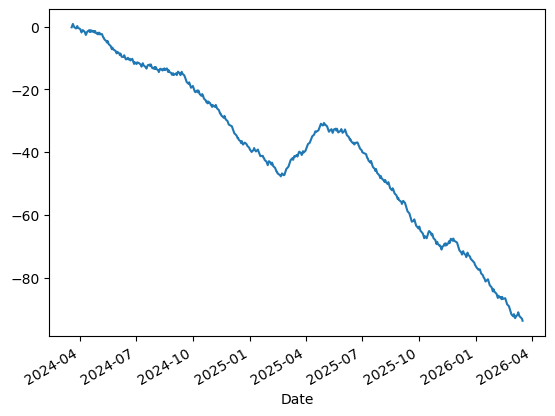

In [ ]:
# PNL from BUYING 0DTE iron condors
pnls['pnl_iron_condor']['cum_pnl'].plot()

Selling 0DTE Iron Condors is a profitable strategy for vol levels > 17%.
The main implementation problem is liquidity.

<Axes: xlabel='Date'>

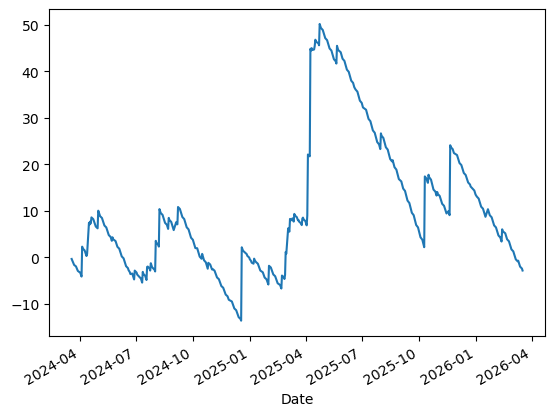

In [ ]:
# Note that the PNL from buying the lower delta puts provides a tail-risk protection. 
# This confirms that is is key to sell put spreads and not outright puts.
pnls['pnl_put_long']['cum_pnl'].plot()